# EDA — California Housing

Exploratory look at the raw dataset that feeds the automated pipeline.
The pipeline itself lives in `code/`; this notebook only documents *why*
the cleaning and feature-engineering steps in stage 1 and stage 2 look the way
they do.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "code" / "models"))

raw = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "housing.csv")
print(raw.shape)
raw.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 1. Missing values

`total_bedrooms` is the only column with gaps — stage 1 imputes them with the median.

In [2]:
raw.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 2. The target is capped

`median_house_value` has a spike at 500001: every district above the cap was
clipped to it when the dataset was built. Those rows are recording artifacts,
not observations, so stage 1 drops them.

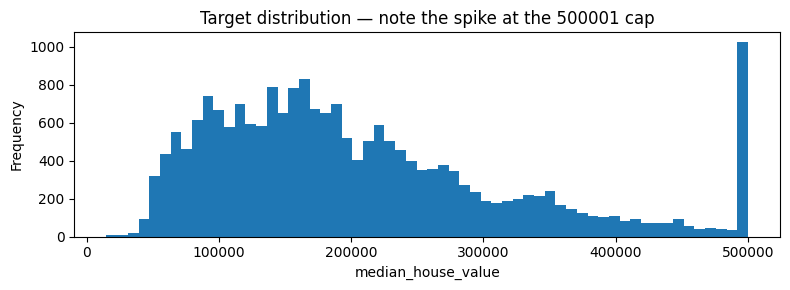

rows at the cap: 992


In [3]:
ax = raw["median_house_value"].plot(kind="hist", bins=60, figsize=(8, 3))
ax.set_xlabel("median_house_value")
ax.set_title("Target distribution — note the spike at the 500001 cap")
plt.tight_layout()
plt.show()

print("rows at the cap:", (raw["median_house_value"] >= 500_000).sum())

## 3. Heavy-tailed count columns

`total_rooms`, `total_bedrooms`, `population` and `households` are block totals
with very long right tails. Stage 1 trims them with an IQR rule (factor 3, so
only the extreme tail goes).

In [4]:
cols = ["total_rooms", "total_bedrooms", "population", "households"]
raw[cols].describe().T[["mean", "50%", "75%", "max"]]

,mean,50%,75%,max
total_rooms,2635.763081,2127.0,3148.0,39320.0
total_bedrooms,537.870553,435.0,647.0,6445.0
population,1425.476744,1166.0,1725.0,35682.0
households,499.539680,409.0,605.0,6082.0


## 4. Why ratios instead of raw counts

A district with 5000 rooms means nothing on its own — it only becomes
informative relative to the number of households. Stage 2 therefore derives
`rooms_per_household`, `bedrooms_per_room` and `population_per_household`.
Their correlation with the target is stronger than that of the raw counts.

In [5]:
from features import build_features

features = build_features(raw.dropna(subset=["total_bedrooms"]))
joined = features.join(raw["median_house_value"])
(
    joined.select_dtypes("number")
    .corr()["median_house_value"]
    .drop("median_house_value")
    .sort_values(key=abs, ascending=False)
    .to_frame("corr_with_target")
)

,corr_with_target
median_income,0.688355
bedrooms_per_room,-0.255880
rooms_per_household,0.151344
latitude,-0.144638
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
longitude,-0.045398
population,-0.025300


## 5. Categorical feature

`ocean_proximity` is one-hot encoded inside the model pipeline
(`handle_unknown="ignore"`, so an unseen category at serving time does not
crash the API).

In [6]:
raw["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64